In [1]:
using Pkg
Pkg.activate("../.")
using ValueFunctionIterations
using LaTeXStrings
Pkg.status("ValueFunctionIterations")
include("analysis/coverage.jl")

  Activating project at `~/github/FisheriesInsuranceModel`


Status `~/github/FisheriesInsuranceModel/Project.toml`
  [dc40bd75] ValueFunctionIterations v0.7.7 `https://github.com/Jack-H-Buckner/ValueFunctionIterations.jl.git#master`


plot_coverage_by_budget

(5, 300)

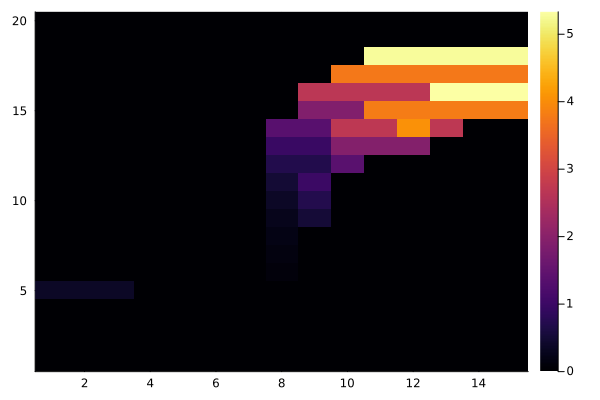

In [4]:
function coverage_levels(prob)
    # non bankrupt states only; the bankrupt branch carries a degenerate grid
    states = prob.V.states[:, prob.V.states[1, :] .== 1]
    states = states[:, states[5,:] .== 1.0]
    states = states[:, states[4,:] .== 0.0]
    print(size(states))

    # RegularGridBspline stores the axis ranges in `grid` and their lengths in
    # `dims` (see ValueFunctions.jl); `dims` is what reshape needs.
    bspline = prob.V.Bslines[1]
    dims = (20,15,1,1)#bspline.dims
    grid = bspline.grid

    u_opt = ValueFunctionIterations.policy(states, prob.u, prob.X, prob.R,
                                           prob.F, prob.p, prob.δ, prob.V)
    η_s = reshape(u_opt[2, :], dims...)
    η̄_s = mapslices(s -> price_per_exposure(El(s, prob.p), prob.p.cf, prob.p.cv),
                    states, dims = 1)
    η̄_s = reshape(η̄_s, dims...)

    return (η = η_s, η̄ = η̄_s, coverage = η_s ./ η̄_s, grid = grid)
end
using Plots
problem = rebuild_problem("RA_int_pr50_re50")
cov_pr50 = coverage_levels(problem.prob)
η_s_50, η̄_s_50, state_grid = cov_pr50
p1 = Plots.heatmap(η_s_50[:,:,1,1]./η̄_s_50[:,:,1,1])
p1

(5, 300)

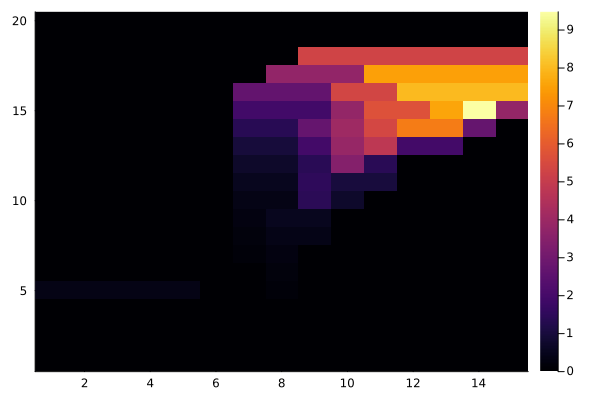

In [6]:
problem = rebuild_problem("RA_int_pr100_re100")
cov_pr100 = coverage_levels(problem.prob)
η_s_100, η̄_s_100, state_grid = cov_pr100
p1 = Plots.heatmap(η_s_100[:,:,1,1]./η̄_s_100[:,:,1,1])
p1

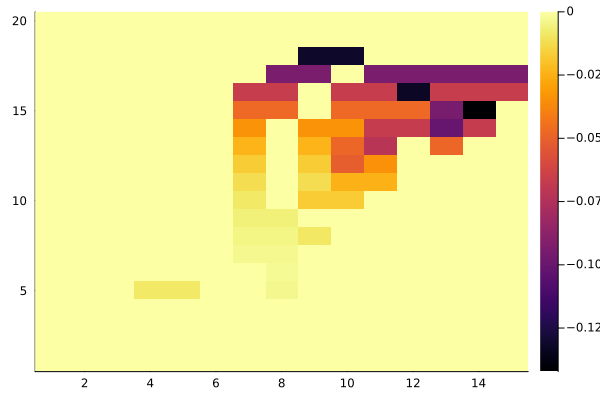

In [7]:
Plots.heatmap((η_s_50 .- η_s_100)[:,:,1,1])

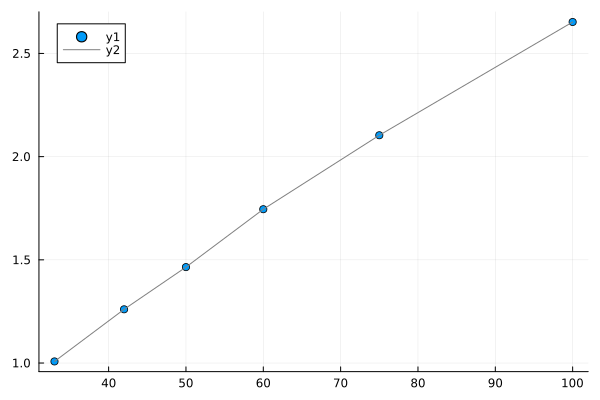

In [10]:
scenarios = ["RA_int_pr100_re100","RA_int_pr75_re100","RA_int_pr60_re100",
            "RA_int_pr50_re100","RA_int_pr42_re100","RA_int_pr33_re100"]
pr = [100,75,60,50,42,33]
coverage_re = zeros(6)
premium_re = zeros(6)
i = 0
problem = rebuild_problem(scenarios[1])
sim_states = stationary_states(problem.prob.p, problem.Xmc; burnin = 500)
for sc in scenarios
    i +=1
    problem = rebuild_problem(sc)
    sol = coverage_by_budget(problem.prob, sim_states, [1.0] ;nmax = 250)[1]
    coverage_re[i] = sol.mean_coverage
    premium_re[i] = sol.mean_premium 
end 

Plots.scatter(pr,coverage_re)
Plots.plot!(pr,coverage_re, color = "grey")

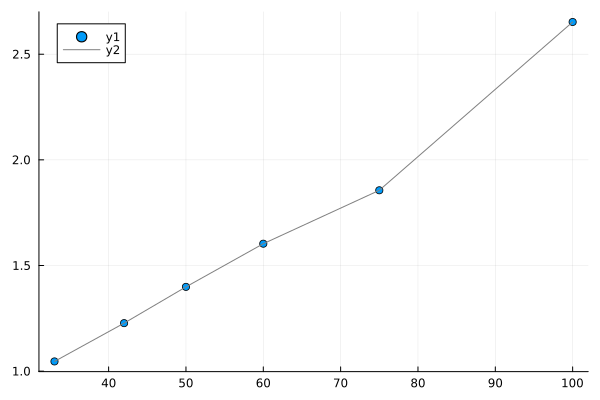

In [11]:

scenarios = ["RA_int_pr100_re100","RA_int_pr75_re75","RA_int_pr60_re60",
            "RA_int_pr50_re50","RA_int_pr42_re42","RA_int_pr33_re33"]
pr = [100,75,60,50,42,33]
coverage = zeros(6)
premium = zeros(6)
i = 0
for sc in scenarios
    i +=1
    problem = rebuild_problem(sc)
    sol = coverage_by_budget(problem.prob, sim_states, [1.0] ;nmax = 250)[1]
    coverage[i] = sol.mean_coverage
    premium[i] = sol.mean_premium 
end 

Plots.scatter(pr,coverage)
Plots.plot!(pr,coverage, color = "grey")

In [ ]:
scenarios = ["RA_int_pr100_re100_cv50", "RA_int_pr75_re75_cv50",
                "RA_int_pr60_re60_cv50", "RA_int_pr50_re50_cv50"]

pr = [100,75,60,50]
coverage_cv50 = zeros(4)
premium_cv50 = zeros(4)
i = 0
sim_states = stationary_states(problem.prob.p, problem.Xmc; burnin = 500)
for sc in scenarios
    i +=1
    problem = rebuild_problem(sc)
    sol = coverage_by_budget(problem.prob, sim_states, [1.0] ;nmax = 250)[1]
    coverage_cv50[i] = sol.mean_coverage
    premium_cv50[i] = sol.mean_premium 
end 



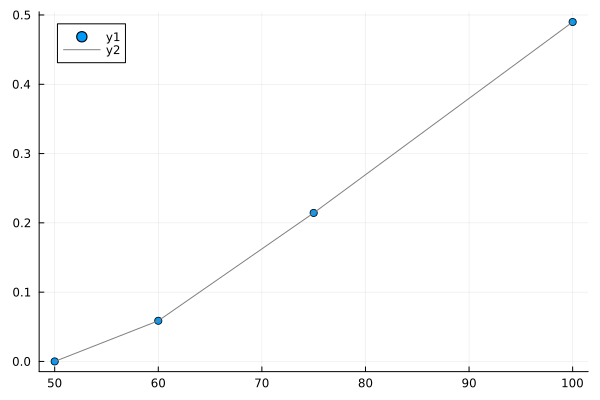

In [14]:
Plots.scatter(pr,coverage_cv50)
Plots.plot!(pr,coverage_cv50, color = "grey")

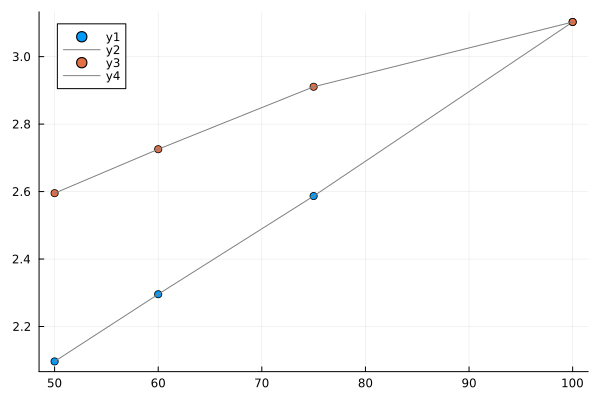

In [79]:
Plots.scatter(pr,coverage_re, c=1)
Plots.plot!(pr,coverage_re, color = "grey")

Plots.scatter!(pr,coverage, c=2)
Plots.plot!(pr,coverage, color = "grey")

In [ ]:

value_diff_100 = value_diff_by_budget("no_RA_int_pr100_re100"; n_sim = 2000,budgets = [1.0])[1]
value_diff_50 = value_diff_by_budget("no_RA_int_pr50_re100"; n_sim = 2000,budgets = [1.0])[1]

(budget = 1.0, savings = -1.0, mean_value_ins = 12.697206964937596, mean_value_no = 11.506229627192544, mean_value_diff = 1.1909773377450537, q10_value_diff = 0.9885365819216558, q90_value_diff = 1.355007221009849, mean_ce_ins = 1.6348603482468806, mean_ce_no = 1.5753114813596276, pct_increase_CE = 3.780132855748458, pct_increase_consumption = 10.350717622829544, frac_better = 1.0, n_states = 2000)

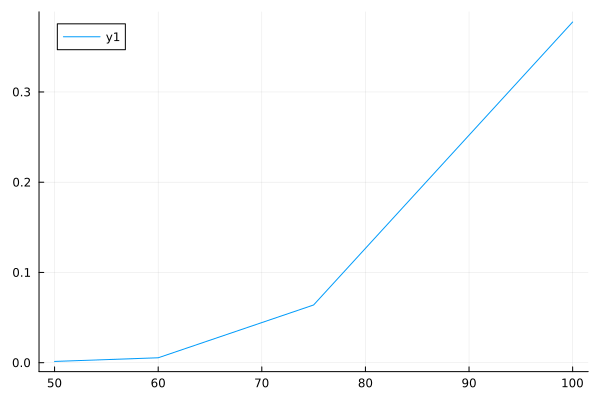

In [28]:
include("analysis/value_diffs.jl")
value_diff_100_cv50 = value_diff_by_budget("RA_int_pr100_re100_cv50"; n_sim = 2000,budgets = [1.0])[1]
value_diff_75_cv50 = value_diff_by_budget("RA_int_pr75_re75_cv50"; n_sim = 2000,budgets = [1.0])[1]
value_diff_60_cv50 = value_diff_by_budget("RA_int_pr60_re60_cv50"; n_sim = 2000,budgets = [1.0])[1]
value_diff_50_cv50 = value_diff_by_budget("RA_int_pr50_re50_cv50"; n_sim = 2000,budgets = [1.0])[1]

pr_cv50 = [100,75,60,50]
value_diff_cv50 = zeros(4)
value_diff_cv50[1] = value_diff_100_cv50.pct_increase_CE
value_diff_cv50[2] = value_diff_75_cv50.pct_increase_CE
value_diff_cv50[3] = value_diff_60_cv50.pct_increase_CE 
value_diff_cv50[4] = value_diff_50_cv50.pct_increase_CE 
Plots.plot(pr_cv50,value_diff_cv50)

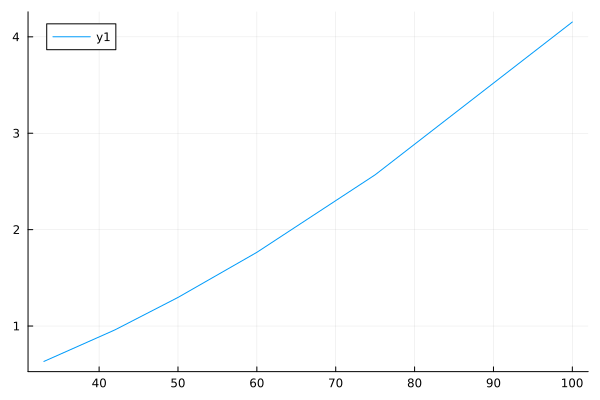

In [30]:
include("analysis/value_diffs.jl")
value_diff_100 = value_diff_by_budget("RA_int_pr100_re100"; n_sim = 2000,budgets = [1.0])[1]
value_diff_75 = value_diff_by_budget("RA_int_pr75_re75"; n_sim = 2000,budgets = [1.0])[1]
value_diff_60 = value_diff_by_budget("RA_int_pr60_re60"; n_sim = 2000,budgets = [1.0])[1]
value_diff_50 = value_diff_by_budget("RA_int_pr50_re50"; n_sim = 2000,budgets = [1.0])[1]
value_diff_42 = value_diff_by_budget("RA_int_pr42_re42"; n_sim = 2000,budgets = [1.0])[1]
value_diff_33 = value_diff_by_budget("RA_int_pr33_re33"; n_sim = 2000,budgets = [1.0])[1]


value_diff = zeros(6)
pr = [100,75,60,50,42,33]
value_diff[1] = value_diff_100.pct_increase_CE 
value_diff[2] = value_diff_75.pct_increase_CE 
value_diff[3] = value_diff_60.pct_increase_CE
value_diff[4] = value_diff_50.pct_increase_CE 
value_diff[5] = value_diff_42.pct_increase_CE
value_diff[6] = value_diff_33.pct_increase_CE 
Plots.plot(pr,value_diff)

In [42]:
Plots.plot(pr_cv50,value_diff_cv50, color = "grey", label = "")
Plots.plot!(pr, value_diff, color = "grey", label = "")
Plots.scatter!(pr_cv50,value_diff_cv50, color = "white", label = "loading factor 50%")
Plots.scatter!(pr,value_diff, color = "grey", label = "loading factor 0%")
Plots.plot!(xlab = "Index accuracy (precision & recall)",
            ylab = "Increase in utility with insurance \n (certainty equivalents)",
            size = (400,300), legendfontsize = 10,
            tickfontsize = 10)
savefig("figures/change_in_utility.png")

"/Users/johnbuckner/github/FisheriesInsuranceModel/index_model/figures/change_in_utility.png"